# 31 — `cartogram`

A choropleth colours a region but leaves its size alone, so a tiny region with a huge value is easy to miss and a
vast empty one dominates the page. `Map.cartogram` attacks that directly: it **scales each polygon about its own
centroid** in proportion to a value, so the thing you are measuring controls the ink.

By the end you will be able to build a cartogram from a polygon collection, pair the scaling with a colour, and
control how extreme the distortion gets.

API: [`Map.cartogram`](../../reference/static_map.md).

**Setup** — the gallery's standard preamble, plus `geopandas` for one spatial join.

In [1]:
%matplotlib inline
from pathlib import Path

import matplotlib.pyplot as plt
from pyramids.feature import FeatureCollection

from digitalearth.static import Map

# The notebook's own folder is the kernel's working directory, so the bundled
# example data sits three levels up: docs/examples/plots -> repo root.
DATA = Path("../../../examples/data")

import geopandas as gpd


## The data

Two bundled layers: Germany's 16 federal states (geoBoundaries ADM1) and the 34 Rhine discharge gauges.

In [2]:
states = FeatureCollection.read_file(str(DATA / "germany_adm1.geojson"))
gauges = FeatureCollection.read_file(str(DATA / "rhine_gauges.geojson"))
print(f"{len(states)} states (EPSG:{states.crs.to_epsg()}), {len(gauges)} gauges")
states[["shapeName", "shapeISO"]].head()

16 states (EPSG:4326), 34 gauges


C:\python-environments\pixi\envs\digitalearth-4838541935417106159\envs\dev\Lib\site-packages\pyogrio\raw.py:200: RuntimeWarning: Several features with id = 5 have been found. Altering it to be unique. This warning will not be emitted anymore for this layer
  return ogr_read(


,shapeName,shapeISO
0,Baden-Württemberg,DE-BW
1,Bayern,DE-BY
2,Berlin,DE-BE
3,Brandenburg,DE-BB
4,Bremen,DE-HB


## Giving each polygon a value

A cartogram needs one number per polygon. The states carry no measurement of their own, so we count **how many
Rhine gauges fall inside each state** — a real quantity, and one whose geography is interesting: the Rhine
corridor states should dominate.

In [3]:
inside = gpd.sjoin(
    gauges.to_crs(states.crs), states[["shapeName", "geometry"]], how="inner", predicate="within"
)
counts = inside.groupby("shapeName").size().rename("gauges")
states = FeatureCollection(states.merge(counts, on="shapeName", how="left").fillna({"gauges": 0}))
states["gauges"] = states["gauges"].astype(int)

In [4]:
states[["shapeName", "gauges"]].sort_values("gauges", ascending=False).head(8)

,shapeName,gauges
10,Rheinland-Pfalz,13
9,Nordrhein-Westfalen,9
1,Bayern,5
0,Baden-Württemberg,4
6,Hessen,3
11,Saarland,1
3,Brandenburg,0
2,Berlin,0


Rheinland-Pfalz holds 13 of the 34 gauges, North Rhine-Westphalia 9, and ten states hold none at all. That is a
very uneven distribution — exactly the case where a cartogram says more than a colour ramp.

## The baseline: a choropleth

Start with the undistorted map, so the cartogram has something to be compared against. Here the geography is
true and only the colour varies.

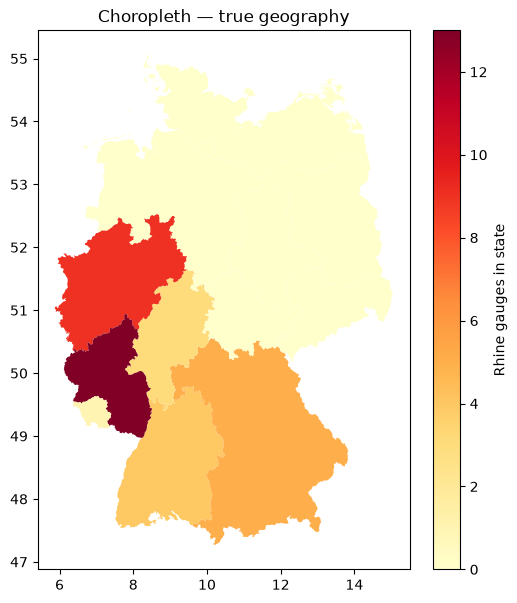

In [5]:
m = Map(crs=4326, figsize=(6, 7))
m.choropleth(states, "gauges", cmap="YlOrRd")
m.colorbar(label="Rhine gauges in state")
m.set_title("Choropleth — true geography")
m.fig;

The signal is there, but Bavaria and Lower Saxony — big states with few or no gauges — take most of the page,
while tiny gauge-rich Saarland is almost invisible. Area is doing the opposite of the story's bidding.

## The cartogram

`scale=` names the column that drives the size. Each polygon shrinks or grows about its centroid, so it stays
roughly where it belongs while its area now encodes the value.

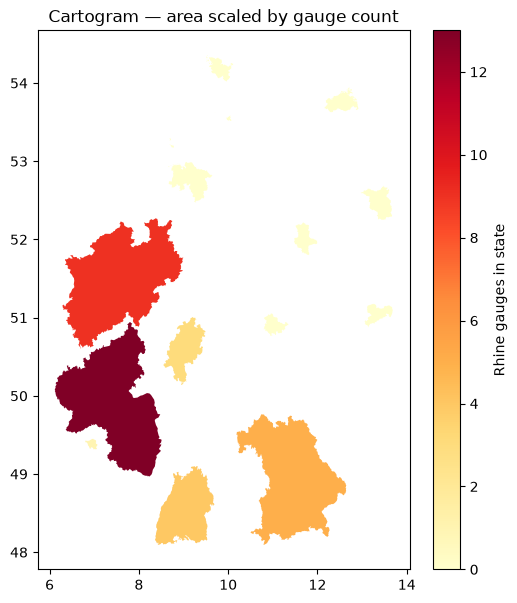

In [6]:
m = Map(crs=4326, figsize=(6, 7))
m.cartogram(states, scale="gauges", column="gauges", cmap="YlOrRd")
m.colorbar(label="Rhine gauges in state")
m.set_title("Cartogram — area scaled by gauge count")
m.fig;

Now the map reads the way the data does. The Rhine corridor — Rheinland-Pfalz, North Rhine-Westphalia, Hessen,
Baden-Württemberg — swells into the centre, and the ten gaugeless states collapse to slivers. The silhouette of
Germany is still legible enough to orient by, which is the point of centroid scaling: it distorts area without
moving regions away from where the reader expects them.

Note `scale=` and `column=` are separate arguments. Passing both, as here, is the clearest form — size *and*
colour carry the same variable, so they reinforce each other. Pass different columns to encode two variables at
once.

## Controlling the distortion with `limits`

`limits` is the `(min, max)` scale factor the values are mapped onto. The default `(0.2, 1.0)` shrinks the
smallest value to a fifth of its true size and leaves the largest untouched.

| argument | meaning | typical value |
|---|---|---|
| `features` | the polygon collection | a polygon `FeatureCollection` |
| `scale` | column driving each polygon's size | a numeric column name |
| `column` | column driving each polygon's colour | often the same column |
| `limits` | `(min, max)` scale factors | `(0.2, 1.0)` default; widen for more contrast |

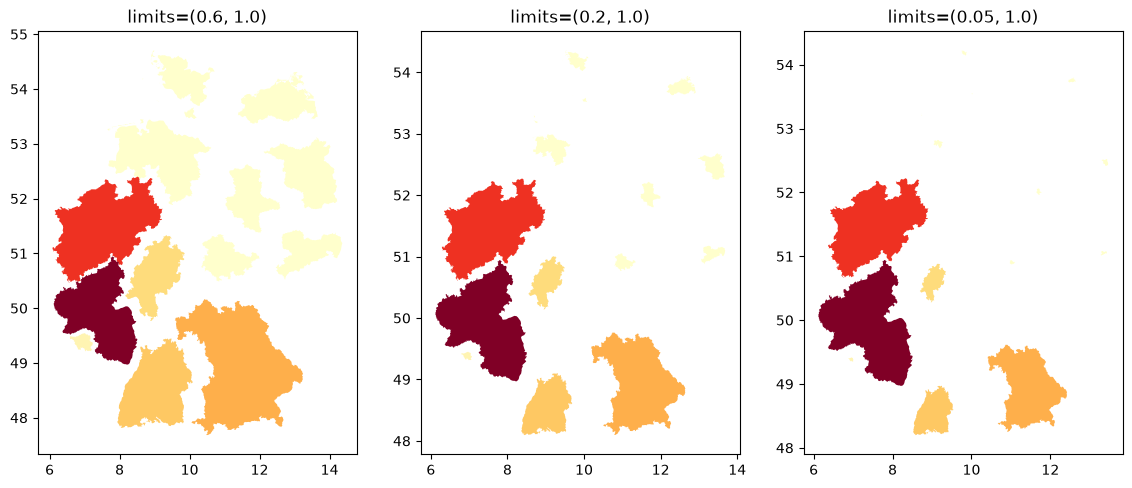

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5.5))
for ax, limits in zip(axes, ((0.6, 1.0), (0.2, 1.0), (0.05, 1.0))):
    panel = Map(ax=ax, crs=4326)
    panel.cartogram(states, scale="gauges", column="gauges", cmap="YlOrRd", limits=limits)
    ax.set_title(f"limits={limits}")
fig;

Left: barely distorted — honest about geography, weak about the data. Middle: the default balance. Right: the
empty states nearly vanish, which makes the gauge network unmistakable at the cost of a map you can hardly
recognise. Choose with the audience in mind; a cartogram is a rhetorical device as much as a measurement.

## Takeaway

- A cartogram makes **area carry the value**, fixing the choropleth's bias toward whatever is physically large.
- `scale=` sizes, `column=` colours — same column to reinforce one variable, different columns for two.
- `limits` tunes how far geography bends; more distortion means more signal and less recognisability.
- Scaling is about each polygon's centroid, so regions stay put and the map stays readable.

Next: [`32_lines`](32_lines.ipynb) moves from polygons to line features.